In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


accessing data from drive


In [2]:
import pandas as pd
import numpy as np

file_path = "/content/drive/MyDrive/flight_pricing_dataset.csv"

df = pd.read_csv(file_path)

checking the properties of dataset like shape,columns in it and properties of the data like dtype and values.


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 100000
Columns: 18


In [4]:
df.head()
df.dtypes

,0
Flight_ID,object
Airline,object
Source,object
Destination,object
Departure_Date,object
Departure_Time,object
Arrival_Time,object
Duration,object
Total_Stops,object
Distance_km,object


In [5]:
print(df.columns.tolist())

['Flight_ID', 'Airline', 'Source', 'Destination', 'Departure_Date', 'Departure_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Distance_km', 'Travel_Class', 'Days_Before_Departure', 'Season', 'Weekday', 'Aircraft_Type', 'Booking_Channel', 'Passenger_Count', 'Price']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Flight_ID              100000 non-null  object
 1   Airline                95120 non-null   object
 2   Source                 95085 non-null   object
 3   Destination            95119 non-null   object
 4   Departure_Date         95073 non-null   object
 5   Departure_Time         95132 non-null   object
 6   Arrival_Time           95211 non-null   object
 7   Duration               94958 non-null   object
 8   Total_Stops            95095 non-null   object
 9   Distance_km            95077 non-null   object
 10  Travel_Class           95137 non-null   object
 11  Days_Before_Departure  95216 non-null   object
 12  Season                 95224 non-null   object
 13  Weekday                95280 non-null   object
 14  Aircraft_Type          95148 non-null   object
 15  B

In [7]:
df.describe(include="all").T

,count,unique,top,freq
Flight_ID,100000,98039,FL119204,3
Airline,95120,39,Singapore Airlines,7864
Source,95085,54,Chennai,3519
Destination,95119,54,Goa,3503
Departure_Date,95073,730,2025-04-05,168
Departure_Time,95132,576,09:50,242
Arrival_Time,95211,2880,06:24,64
Duration,94958,5111,1h 10m,377
Total_Stops,95095,6,1,26710
Distance_km,95077,59484,150,590


checking missing values and duplicate data entries and invalid data entries


In [8]:
missing = df.isnull().sum()

print(missing)

Flight_ID                   0
Airline                  4880
Source                   4915
Destination              4881
Departure_Date           4927
Departure_Time           4868
Arrival_Time             4789
Duration                 5042
Total_Stops              4905
Distance_km              4923
Travel_Class             4863
Days_Before_Departure    4784
Season                   4776
Weekday                  4720
Aircraft_Type            4852
Booking_Channel          4962
Passenger_Count          4826
Price                    5053
dtype: int64


In [9]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

print(missing_percentage)

Price                    5.053
Duration                 5.042
Booking_Channel          4.962
Departure_Date           4.927
Distance_km              4.923
Source                   4.915
Total_Stops              4.905
Destination              4.881
Airline                  4.880
Departure_Time           4.868
Travel_Class             4.863
Aircraft_Type            4.852
Passenger_Count          4.826
Arrival_Time             4.789
Days_Before_Departure    4.784
Season                   4.776
Weekday                  4.720
Flight_ID                0.000
dtype: float64


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1961


In [11]:
print("Duplicate Flight IDs:", df["Flight_ID"].duplicated().sum())

Duplicate Flight IDs: 1961


In [12]:
print("AIRLINES")
print(df["Airline"].value_counts())

print("\nSOURCE")
print(df["Source"].value_counts())

print("\nDESTINATION")
print(df["Destination"].value_counts())

print("\nTRAVEL CLASS")
print(df["Travel_Class"].value_counts())

print("\nTOTAL STOPS")
print(df["Total_Stops"].value_counts())

print("\nSEASON")
print(df["Season"].value_counts())

print("\nWEEKDAY")
print(df["Weekday"].value_counts())

print("\nAIRCRAFT TYPE")
print(df["Aircraft_Type"].value_counts())

print("\nBOOKING CHANNEL")
print(df["Booking_Channel"].value_counts())

AIRLINES
Airline
Singapore Airlines    7864
Etihad Airways        7802
Lufthansa             7786
Emirates              7722
Thai Airways          7708
Qatar Airways         7667
British Airways       7598
Vistara               5649
Air India             4895
Indigo                4677
AirAsia India         4649
GoFirst               4630
SpiceJet              4602
air india              740
AIR INDIA              713
thai airways           564
SINGAPORE AIRLINES     546
BRITISH AIRWAYS        536
lufthansa              527
singapore airlines     521
emirates               515
LUFTHANSA              513
etihad airways         505
QATAR AIRWAYS          505
british airways        505
qatar airways          501
EMIRATES               497
THAI AIRWAYS           482
ETIHAD AIRWAYS         467
vistara                388
VISTARA                378
GOFIRST                327
airasia india          320
AIRASIA INDIA          318
spicejet               309
SPICEJET               305
indigo     

creating a list of numerical columns for clarity

In [13]:
numerical_columns = [
    "Distance_km",
    "Days_Before_Departure",
    "Passenger_Count",
    "Price"
]

df[numerical_columns].describe()

,Distance_km,Days_Before_Departure,Passenger_Count,Price
count,95077,95216,95174,94947
unique,59484,341,12,78725
top,150,0,1,200000
freq,590,3554,39079,8989


fixing the null values and invalid ones in duration ,departure date, arrival time

In [14]:
print(df["Duration"].head(30).to_string())

0         1.67
1       0h 45m
2        14.80
3       3h 11m
4        13.93
5      16h 47m
6       1h 28m
7       5h 27m
8      17h 04m
9       3h 20m
10     177 min
11         NaN
12      0h 59m
13         NaN
14      2h 02m
15     155 min
16     22h 40m
17     18h 45m
18      6h 04m
19        1.98
20      2h 38m
21         NaN
22        4.38
23     900 min
24    1039 min
25      0h 49m
26      3h 27m
27     20h 26m
28      2h 16m
29      5h 41m


In [15]:
print(df["Duration"].unique()[:50])

['1.67' '0h 45m' '14.80' '3h 11m' '13.93' '16h 47m' '1h 28m' '5h 27m'
 '17h 04m' '3h 20m' '177 min' nan '0h 59m' '2h 02m' '155 min' '22h 40m'
 '18h 45m' '6h 04m' '1.98' '2h 38m' '4.38' '900 min' '1039 min' '0h 49m'
 '3h 27m' '20h 26m' '2h 16m' '5h 41m' '3h 16m' '4h 52m' '1346 min'
 '146 min' '423 min' '14h 29m' '137 min' '14h 22m' '959 min' '660 min'
 '71 min' '4h 58m' '2h 14m' '339 min' '3h 33m' '17h 15m' '10.83' '2h 39m'
 '8h 33m' '14h 21m' '5h 16m' '1h 09m']


fixing null, invaid data entries in departure time and arrival time as they have diffrent way to represent time and is not uniform

In [16]:
print(df["Departure_Date"].head(20).to_string())

0     2025-08-02
1     2025-06-05
2     2025-02-11
3     2025-04-19
4     2026-07-05
5     2025-06-25
6     2025-02-16
7     2026-10-08
8     2025-10-13
9     2026-03-30
10    2025-01-12
11    2025-04-29
12    2026-02-05
13    2026-05-24
14    2026-06-24
15    2025-03-28
16    2025-07-08
17    2026-10-10
18    2025-03-22
19    2025-06-25


In [17]:
print(df["Departure_Date"].dtype)

object


In [18]:
print("Departure:")
print(df["Departure_Time"].head(20).to_string())

print("\nArrival:")
print(df["Arrival_Time"].head(20).to_string())

Departure:
0      8:10 PM
1        12:10
2      5:05 PM
3        07:05
4     10:40 PM
5      4:15 AM
6      1:35 AM
7      9:55 AM
8      5:45 AM
9      8:15 AM
10       13:30
11       23:30
12       22:50
13       19:25
14       13:50
15       15:05
16     4:50 PM
17     5:20 AM
18    10:15 PM
19     7:25 PM

Arrival:
0        21:50
1        12:55
2      7:53 AM
3     10:16 AM
4        12:36
5        21:02
6      3:02 AM
7      3:21 PM
8        22:49
9     11:35 AM
10       16:26
11       04:04
12       23:48
13     4:54 PM
14       15:51
15     5:39 PM
16       15:29
17       00:05
18     4:19 AM
19       21:23


creating df_clean to store cleaned dataframe


In [19]:
df_clean = df.copy()

removing duplicate entries from the dataframe


In [20]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 1961


In [21]:
df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (98039, 18)


In [22]:
categorical_columns = [
    "Airline",
    "Source",
    "Destination",
    "Travel_Class",
    "Season",
    "Weekday",
    "Aircraft_Type",
    "Booking_Channel"
]

for column in categorical_columns:
    df_clean[column] = (
        df_clean[column]
        .astype("string")
        .str.strip()
    )

cleaning airline column that have same airline with diffrent font styles

In [23]:
print(df_clean["Airline"].value_counts().head(20))

Airline
Singapore Airlines    7723
Etihad Airways        7653
Lufthansa             7646
Emirates              7569
Thai Airways          7549
Qatar Airways         7521
British Airways       7436
Vistara               5531
Air India             4780
Indigo                4594
AirAsia India         4555
GoFirst               4533
SpiceJet              4514
air india              724
AIR INDIA              694
thai airways           555
SINGAPORE AIRLINES     536
BRITISH AIRWAYS        525
lufthansa              515
singapore airlines     513
Name: count, dtype: Int64


In [24]:
airline_values = (
    df_clean["Airline"]
    .dropna()
    .unique()
)

print(sorted(airline_values))

['AIR INDIA', 'AIRASIA INDIA', 'Air India', 'AirAsia India', 'BRITISH AIRWAYS', 'British Airways', 'EMIRATES', 'ETIHAD AIRWAYS', 'Emirates', 'Etihad Airways', 'GOFIRST', 'GoFirst', 'INDIGO', 'Indigo', 'LUFTHANSA', 'Lufthansa', 'QATAR AIRWAYS', 'Qatar Airways', 'SINGAPORE AIRLINES', 'SPICEJET', 'Singapore Airlines', 'SpiceJet', 'THAI AIRWAYS', 'Thai Airways', 'VISTARA', 'Vistara', 'air india', 'airasia india', 'british airways', 'emirates', 'etihad airways', 'gofirst', 'indigo', 'lufthansa', 'qatar airways', 'singapore airlines', 'spicejet', 'thai airways', 'vistara']


In [25]:
df_clean["Airline"] = (
    df_clean["Airline"]
    .str.lower()
    .str.strip()
    .str.title()
)

In [26]:
print(df_clean["Airline"].value_counts())

Airline
Singapore Airlines    8772
Lufthansa             8663
Etihad Airways        8614
Thai Airways          8576
Emirates              8570
Qatar Airways         8503
British Airways       8456
Vistara               6287
Air India             6198
Airasia India         5182
Indigo                5176
Gofirst               5142
Spicejet              5112
Name: count, dtype: Int64


cleaning source,destination and travel class

In [27]:
df_clean["Source"] = (
    df_clean["Source"]
    .str.lower()
    .str.strip()
    .str.title()
)

df_clean["Destination"] = (
    df_clean["Destination"]
    .str.lower()
    .str.strip()
    .str.title()
)

In [28]:
print("Sources:")
print(df_clean["Source"].value_counts())

print("\nDestinations:")
print(df_clean["Destination"].value_counts())

Sources:
Source
Chennai              3456
Pune                 3431
Doha                 3427
Singapore            3426
New York             3412
Hyderabad            3406
Bangkok              3405
Dubai                3396
Frankfurt            3393
Ahmedabad            3391
Bangalore            3382
Jaipur               3370
Mumbai               3364
Sydney               3363
London               3332
Kolkata              3315
Delhi                3299
Goa                  3283
Goi                   965
Jaipur Airport        945
Bkk                   937
Del                   935
Dxb                   932
Ahmedabad Airport     930
Bom                   925
Kolkata Airport       919
Blr                   918
Lhr                   916
Dubai Airport         914
Jfk                   913
Maa                   910
Hyd                   908
Sin                   904
Mumbai Airport        903
New York Airport      902
Delhi Airport         900
Hyderabad Airport     900
Pune Airport          

In [29]:
print(df_clean["Travel_Class"].value_counts(dropna=False))

Travel_Class
Economy            63604
Premium Economy    14770
Business           11030
<NA>                4763
First               3872
Name: count, dtype: Int64


In [30]:
df_clean["Travel_Class"] = (
    df_clean["Travel_Class"]
    .str.lower()
    .str.strip()
    .str.title()
)

In [31]:
print(df_clean["Travel_Class"].value_counts(dropna=False))

Travel_Class
Economy            63604
Premium Economy    14770
Business           11030
<NA>                4763
First               3872
Name: count, dtype: Int64


In [32]:
df_clean["Departure_Date"] = pd.to_datetime(
    df_clean["Departure_Date"],
    errors="coerce"
)

In [33]:
print(df_clean["Departure_Date"].dtype)

datetime64[ns]


In [34]:
df_clean["Journey_Year"] = (
    df_clean["Departure_Date"].dt.year
)

In [35]:
df_clean["Journey_Month"] = (
    df_clean["Departure_Date"].dt.month
)

In [36]:
df_clean["Journey_Day"] = (
    df_clean["Departure_Date"].dt.day
)

In [37]:
df_clean["Journey_DayOfWeek"] = (
    df_clean["Departure_Date"].dt.dayofweek
)

In [38]:
df_clean[
    [
        "Departure_Date",
        "Journey_Year",
        "Journey_Month",
        "Journey_Day",
        "Journey_DayOfWeek"
    ]
].head(10)

,Departure_Date,Journey_Year,Journey_Month,Journey_Day,Journey_DayOfWeek
0,2025-08-02,2025.0,8.0,2.0,5.0
1,2025-06-05,2025.0,6.0,5.0,3.0
2,2025-02-11,2025.0,2.0,11.0,1.0
3,2025-04-19,2025.0,4.0,19.0,5.0
4,2026-07-05,2026.0,7.0,5.0,6.0
5,2025-06-25,2025.0,6.0,25.0,2.0
6,2025-02-16,2025.0,2.0,16.0,6.0
7,2026-10-08,2026.0,10.0,8.0,3.0
8,2025-10-13,2025.0,10.0,13.0,0.0
9,2026-03-30,2026.0,3.0,30.0,0.0


In [39]:
def convert_time_to_minutes(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    try:
        time_value = pd.to_datetime(value)

        return (
            time_value.hour * 60
            + time_value.minute
        )

    except:
        return np.nan

In [40]:
df_clean["Departure_Minutes"] = (
    df_clean["Departure_Time"]
    .apply(convert_time_to_minutes)
)

In [41]:
df_clean["Departure_Hour"] = (
    df_clean["Departure_Minutes"] // 60
)

In [42]:
df_clean[
    [
        "Departure_Time",
        "Departure_Hour",
        "Departure_Minutes"
    ]
].head(15)

,Departure_Time,Departure_Hour,Departure_Minutes
0,8:10 PM,20.0,1210.0
1,12:10,12.0,730.0
2,5:05 PM,17.0,1025.0
3,07:05,7.0,425.0
4,10:40 PM,22.0,1360.0
5,4:15 AM,4.0,255.0
6,1:35 AM,1.0,95.0
7,9:55 AM,9.0,595.0
8,5:45 AM,5.0,345.0
9,8:15 AM,8.0,495.0


In [43]:
df_clean["Arrival_Minutes"] = (
    df_clean["Arrival_Time"]
    .apply(convert_time_to_minutes)
)

In [44]:
df_clean["Arrival_Hour"] = (
    df_clean["Arrival_Minutes"] // 60
)

In [45]:
df_clean[
    [
        "Arrival_Time",
        "Arrival_Hour",
        "Arrival_Minutes"
    ]
].head(15)

,Arrival_Time,Arrival_Hour,Arrival_Minutes
0,21:50,21.0,1310.0
1,12:55,12.0,775.0
2,7:53 AM,7.0,473.0
3,10:16 AM,10.0,616.0
4,12:36,12.0,756.0
5,21:02,21.0,1262.0
6,3:02 AM,3.0,182.0
7,3:21 PM,15.0,921.0
8,22:49,22.0,1369.0
9,11:35 AM,11.0,695.0


converting duration represented by diff format to minutes

In [46]:
def convert_duration_to_minutes(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    try:

        # Format: 3h 11m
        if "h" in value:

            hour_part = value.split("h")[0].strip()
            hours = float(hour_part)

            minutes = 0

            if "m" in value:
                minute_part = value.split("h")[1]
                minute_part = (
                    minute_part
                    .replace("m", "")
                    .strip()
                )

                if minute_part:
                    minutes = float(minute_part)

            return hours * 60 + minutes

        # Format: 177 min
        elif "min" in value:

            return float(
                value.replace("min", "").strip()
            )

        # Decimal hours: 1.67
        else:

            return float(value) * 60

    except:

        return np.nan

In [47]:
df_clean["Duration_Minutes"] = (
    df_clean["Duration"]
    .apply(convert_duration_to_minutes)
)

In [48]:
df_clean[
    [
        "Duration",
        "Duration_Minutes"
    ]
].head(30)

,Duration,Duration_Minutes
0,1.67,100.2
1,0h 45m,45.0
2,14.80,888.0
3,3h 11m,191.0
4,13.93,835.8
5,16h 47m,1007.0
6,1h 28m,88.0
7,5h 27m,327.0
8,17h 04m,1024.0
9,3h 20m,200.0


In [49]:
df_clean["Duration_Minutes"].describe()

,Duration_Minutes
count,93099.000000
mean,488.028709
std,358.837067
min,45.000000
25%,198.000000
50%,354.000000
75%,731.000000
max,1647.000000


In [50]:
def convert_stops(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    if value in ["non-stop", "non stop", "0"]:
        return 0

    value = (
        value
        .replace("stops", "")
        .replace("stop", "")
        .strip()
    )

    try:
        return float(value)

    except:
        return np.nan

In [51]:
df_clean["Total_Stops_Clean"] = (
    df_clean["Total_Stops"]
    .apply(convert_stops)
)

In [52]:
print(
    df_clean[
        [
            "Total_Stops",
            "Total_Stops_Clean"
        ]
    ].drop_duplicates()
    .sort_values("Total_Stops_Clean")
    .to_string(index=False)
)

Total_Stops  Total_Stops_Clean
          0                0.0
   non-stop                0.0
     1 stop                1.0
          1                1.0
    2 stops                2.0
          2                2.0
        NaN                NaN


In [53]:
numeric_columns = [
    "Distance_km",
    "Days_Before_Departure",
    "Passenger_Count",
    "Price"
]

for column in numeric_columns:

    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )

In [54]:
df_clean[numeric_columns].dtypes

,0
Distance_km,float64
Days_Before_Departure,float64
Passenger_Count,float64
Price,float64


segregating feature engineered columns

In [55]:
engineered_columns = [
    "Journey_Year",
    "Journey_Month",
    "Journey_Day",
    "Journey_DayOfWeek",
    "Departure_Hour",
    "Departure_Minutes",
    "Arrival_Hour",
    "Arrival_Minutes",
    "Duration_Minutes",
    "Total_Stops_Clean"
]

df_clean[engineered_columns].head()

,Journey_Year,Journey_Month,Journey_Day,Journey_DayOfWeek,Departure_Hour,Departure_Minutes,Arrival_Hour,Arrival_Minutes,Duration_Minutes,Total_Stops_Clean
0,2025.0,8.0,2.0,5.0,20.0,1210.0,21.0,1310.0,100.2,0.0
1,2025.0,6.0,5.0,3.0,12.0,730.0,12.0,775.0,45.0,0.0
2,2025.0,2.0,11.0,1.0,17.0,1025.0,7.0,473.0,888.0,1.0
3,2025.0,4.0,19.0,5.0,7.0,425.0,10.0,616.0,191.0,1.0
4,2026.0,7.0,5.0,6.0,22.0,1360.0,12.0,756.0,835.8,0.0


In [56]:
missing_after_engineering = (
    df_clean.isnull().sum()
    .sort_values(ascending=False)
)

print(missing_after_engineering)

Price                    7781
Distance_km              7595
Passenger_Count          6690
Days_Before_Departure    6067
Duration                 4940
Duration_Minutes         4940
Booking_Channel          4871
Journey_Month            4842
Journey_Year             4842
Journey_Day              4842
Journey_DayOfWeek        4842
Departure_Date           4842
Total_Stops_Clean        4821
Total_Stops              4821
Source                   4815
Airline                  4788
Destination              4784
Departure_Hour           4773
Departure_Minutes        4773
Departure_Time           4773
Travel_Class             4763
Aircraft_Type            4755
Arrival_Hour             4701
Arrival_Time             4701
Arrival_Minutes          4701
Season                   4689
Weekday                  4619
Flight_ID                   0
dtype: int64


In [57]:
print(df_clean["Duration_Minutes"].describe())
print(df_clean["Travel_Class"].value_counts(dropna=False))

count    93099.000000
mean       488.028709
std        358.837067
min         45.000000
25%        198.000000
50%        354.000000
75%        731.000000
max       1647.000000
Name: Duration_Minutes, dtype: float64
Travel_Class
Economy            63604
Premium Economy    14770
Business           11030
<NA>                4763
First               3872
Name: count, dtype: Int64


segregating columns that have categorical entries and checking for null entries

In [58]:
categorical_columns = [
    "Airline",
    "Source",
    "Destination",
    "Travel_Class",
    "Season",
    "Weekday",
    "Aircraft_Type",
    "Booking_Channel"
]

for column in categorical_columns:
    df_clean[column] = (
        df_clean[column]
        .astype("string")
        .fillna("Unknown")
    )

In [59]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts(dropna=False))


Airline
Airline
Singapore Airlines    8772
Lufthansa             8663
Etihad Airways        8614
Thai Airways          8576
Emirates              8570
Qatar Airways         8503
British Airways       8456
Vistara               6287
Air India             6198
Airasia India         5182
Indigo                5176
Gofirst               5142
Spicejet              5112
Unknown               4788
Name: count, dtype: Int64

Source
Source
Unknown              4815
Chennai              3456
Pune                 3431
Doha                 3427
Singapore            3426
New York             3412
Hyderabad            3406
Bangkok              3405
Dubai                3396
Frankfurt            3393
Ahmedabad            3391
Bangalore            3382
Jaipur               3370
Mumbai               3364
Sydney               3363
London               3332
Kolkata              3315
Delhi                3299
Goa                  3283
Goi                   965
Jaipur Airport        945
Bkk               

segregating columns with numerical entries and filling missing values with their medians

In [60]:
numerical_features = [
    "Distance_km",
    "Passenger_Count",
    "Days_Before_Departure",
    "Duration_Minutes",
    "Total_Stops_Clean",
    "Departure_Hour",
    "Departure_Minutes",
    "Arrival_Hour",
    "Arrival_Minutes",
    "Journey_Year",
    "Journey_Month",
    "Journey_Day",
    "Journey_DayOfWeek"
]

In [61]:
medians = df_clean[numerical_features].median()

print(medians)

Distance_km              3213.5
Passenger_Count             2.0
Days_Before_Departure      19.0
Duration_Minutes          354.0
Total_Stops_Clean           1.0
Departure_Hour             12.0
Departure_Minutes         720.0
Arrival_Hour               11.0
Arrival_Minutes           719.0
Journey_Year             2026.0
Journey_Month               7.0
Journey_Day                16.0
Journey_DayOfWeek           3.0
dtype: float64


In [62]:
for column in numerical_features:
    df_clean[column] = (
        df_clean[column]
        .fillna(df_clean[column].median())
    )

In [63]:
print(
    df_clean[numerical_features]
    .isnull()
    .sum()
)

Distance_km              0
Passenger_Count          0
Days_Before_Departure    0
Duration_Minutes         0
Total_Stops_Clean        0
Departure_Hour           0
Departure_Minutes        0
Arrival_Hour             0
Arrival_Minutes          0
Journey_Year             0
Journey_Month            0
Journey_Day              0
Journey_DayOfWeek        0
dtype: int64


In [64]:
print(
    df_clean[categorical_columns]
    .isnull()
    .sum()
)

Airline            0
Source             0
Destination        0
Travel_Class       0
Season             0
Weekday            0
Aircraft_Type      0
Booking_Channel    0
dtype: int64


prices has been choosed as the target and creating model dataset with no null price values

In [65]:
print("Missing prices:", df_clean["Price"].isnull().sum())

Missing prices: 7781


In [66]:
model_df = df_clean[
    df_clean["Price"].notna()
].copy()

In [67]:
print("Original cleaned rows:", len(df_clean))
print("Rows with known price:", len(model_df))

Original cleaned rows: 98039
Rows with known price: 90258


In [68]:
print("Rows:", model_df.shape[0])
print("Columns:", model_df.shape[1])

print("\nRemaining missing values:")
print(
    model_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

Rows: 90258
Columns: 28

Remaining missing values:
Duration                 4532
Departure_Date           4472
Total_Stops              4427
Departure_Time           4427
Arrival_Time             4326
Source                      0
Airline                     0
Flight_ID                   0
Destination                 0
Distance_km                 0
Travel_Class                0
Days_Before_Departure       0
Season                      0
Weekday                     0
Aircraft_Type               0
Booking_Channel             0
Passenger_Count             0
Price                       0
Journey_Year                0
Journey_Month               0
Journey_Day                 0
Journey_DayOfWeek           0
Departure_Minutes           0
Departure_Hour              0
Arrival_Minutes             0
Arrival_Hour                0
Duration_Minutes            0
Total_Stops_Clean           0
dtype: int64


In [69]:
cleaned_file_path = (
    "/content/drive/MyDrive/flight_cleaned.csv"
)

df_clean.to_csv(
    cleaned_file_path,
    index=False
)

print("Cleaned dataset saved to:")
print(cleaned_file_path)

Cleaned dataset saved to:
/content/drive/MyDrive/flight_cleaned.csv


In [70]:
model_file_path = (
    "/content/drive/MyDrive/flight_model_data.csv"
)

model_df.to_csv(
    model_file_path,
    index=False
)

print("Model dataset saved to:")
print(model_file_path)

Model dataset saved to:
/content/drive/MyDrive/flight_model_data.csv


we are choosing calculated weekday feature over original due to inconsistencies with the original weekdays

In [71]:
comparison = pd.DataFrame({
    "Original_Weekday": df_clean["Weekday"],
    "Calculated_Weekday": df_clean["Departure_Date"].dt.day_name()
})

comparison.head(20)

,Original_Weekday,Calculated_Weekday
0,Saturday,Saturday
1,Thursday,Thursday
2,Tuesday,Tuesday
3,Saturday,Saturday
4,Sunday,Sunday
5,Wednesday,Wednesday
6,Sunday,Sunday
7,Thursday,Thursday
8,Monday,Monday
9,Monday,Monday


In [72]:
comparison["Match"] = (
    comparison["Original_Weekday"]
    .str.lower()
    ==
    comparison["Calculated_Weekday"]
    .str.lower()
)

print(comparison["Match"].value_counts(dropna=False))

Match
True     88814
<NA>      4842
False     4383
Name: count, dtype: Int64


In [73]:
print(model_df.shape)

(90258, 28)


In [74]:
print(
    model_df.isnull().sum()
    .sort_values(ascending=False)
)

Duration                 4532
Departure_Date           4472
Total_Stops              4427
Departure_Time           4427
Arrival_Time             4326
Source                      0
Airline                     0
Flight_ID                   0
Destination                 0
Distance_km                 0
Travel_Class                0
Days_Before_Departure       0
Season                      0
Weekday                     0
Aircraft_Type               0
Booking_Channel             0
Passenger_Count             0
Price                       0
Journey_Year                0
Journey_Month               0
Journey_Day                 0
Journey_DayOfWeek           0
Departure_Minutes           0
Departure_Hour              0
Arrival_Minutes             0
Arrival_Hour                0
Duration_Minutes            0
Total_Stops_Clean           0
dtype: int64


In [75]:
print(comparison["Match"].value_counts(dropna=False))

Match
True     88814
<NA>      4842
False     4383
Name: count, dtype: Int64


In [76]:
model_features = [
    "Airline",
    "Source",
    "Destination",
    "Duration_Minutes",
    "Total_Stops_Clean",
    "Distance_km",
    "Travel_Class",
    "Days_Before_Departure",
    "Season",
    "Aircraft_Type",
    "Booking_Channel",
    "Passenger_Count",
    "Journey_Year",
    "Journey_Month",
    "Journey_Day",
    "Journey_DayOfWeek",
    "Departure_Hour",
    "Arrival_Hour"
]

defining features for the model and the target

In [77]:
X = model_df[model_features].copy()

y = model_df["Price"].copy()
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (90258, 18)
Target shape: (90258,)


In [78]:
print(X.dtypes)

Airline                  string[python]
Source                   string[python]
Destination              string[python]
Duration_Minutes                float64
Total_Stops_Clean               float64
Distance_km                     float64
Travel_Class             string[python]
Days_Before_Departure           float64
Season                   string[python]
Aircraft_Type            string[python]
Booking_Channel          string[python]
Passenger_Count                 float64
Journey_Year                    float64
Journey_Month                   float64
Journey_Day                     float64
Journey_DayOfWeek               float64
Departure_Hour                  float64
Arrival_Hour                    float64
dtype: object


In [79]:
import matplotlib.pyplot as plt

airline_price = (
    model_df
    .groupby("Airline")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print(airline_price)

Airline
Qatar Airways         101218.814695
Singapore Airlines    100557.631600
Etihad Airways        100368.639326
Emirates               99962.419490
British Airways        99815.269909
Thai Airways           99579.491549
Lufthansa              98799.870113
Unknown                73250.876730
Air India              45521.445734
Vistara                45149.312103
Spicejet               10923.135554
Airasia India          10884.289871
Indigo                 10651.725695
Gofirst                10206.177465
Name: Price, dtype: float64


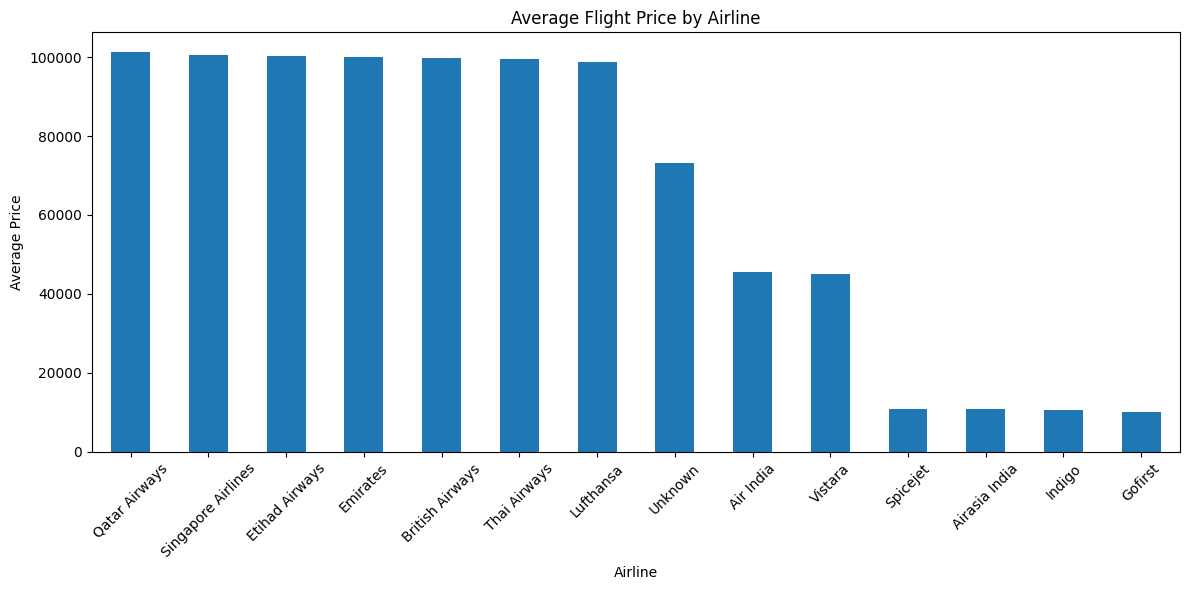

In [80]:
plt.figure(figsize=(12, 6))

airline_price.plot(kind="bar")

plt.title("Average Flight Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/flightwise_airline_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Airline

Airline is a major factor associated with flight price in the dataset. Premium international carriers show substantially higher average fares than several lower-cost carriers. Qatar Airways recorded the highest average price at approximately ₹101,219, while GoFirst, IndiGo, AirAsia India, and SpiceJet were among the lowest. However, these differences may also reflect other factors such as travel class, route distance, and number of stops.

 Travelers should compare multiple airlines for the same route and travel conditions instead of assuming that one airline will always be cheaper.

In [81]:
class_price = (
    model_df
    .groupby("Travel_Class")["Price"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

print(class_price)

                          mean      median  count
Travel_Class                                     
First            134060.754085  184200.855   3550
Business         115806.916136  116471.230  10191
Premium Economy   81949.196527   61339.040  13574
Unknown           74954.494691   50777.260   4391
Economy           59666.916583   39824.330  58552


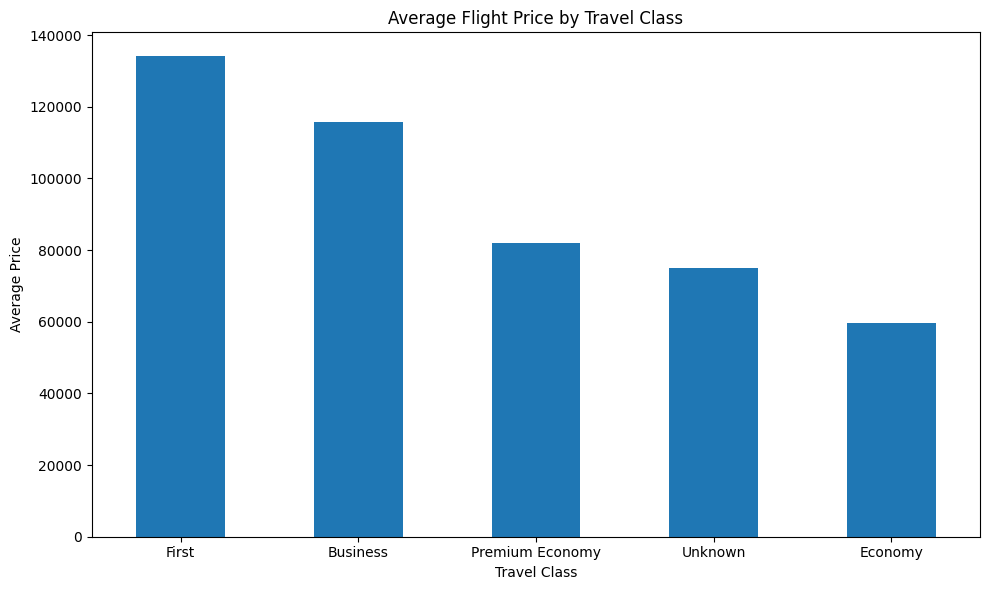

In [82]:
plt.figure(figsize=(10, 6))

class_price["mean"].plot(kind="bar")

plt.title("Average Flight Price by Travel Class")
plt.xlabel("Travel Class")
plt.ylabel("Average Price")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "/content/travel_class_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [83]:
class_price["mean"].sort_values(ascending=False)

,mean
Travel_Class,
First,134060.754085
Business,115806.916136
Premium Economy,81949.196527
Unknown,74954.494691
Economy,59666.916583


In [84]:
files.download("/content/travel_class_vs_price.png")

NameError: name 'files' is not defined

In [85]:
print(class_price)

                          mean      median  count
Travel_Class                                     
First            134060.754085  184200.855   3550
Business         115806.916136  116471.230  10191
Premium Economy   81949.196527   61339.040  13574
Unknown           74954.494691   50777.260   4391
Economy           59666.916583   39824.330  58552


Travel class is one of the strongest factors associated with flight price. First Class has the highest average fare at approximately ₹134,061, followed by Business at ₹115,807 and Premium Economy at ₹81,949. Economy has the lowest average price among known classes at approximately ₹59,667.

Travelers prioritizing affordability should compare Economy and Premium Economy options, while premium cabin travelers should expect substantially higher fares.

In [86]:
stops_price = (
    model_df
    .groupby("Total_Stops_Clean")["Price"]
    .agg(["mean", "median", "count"])
    .sort_index()
)

print(stops_price)

                           mean     median  count
Total_Stops_Clean                                
0.0                61609.096989  32250.895  34574
1.0                78968.050905  59248.890  44500
2.0                84681.120740  71215.500  11184


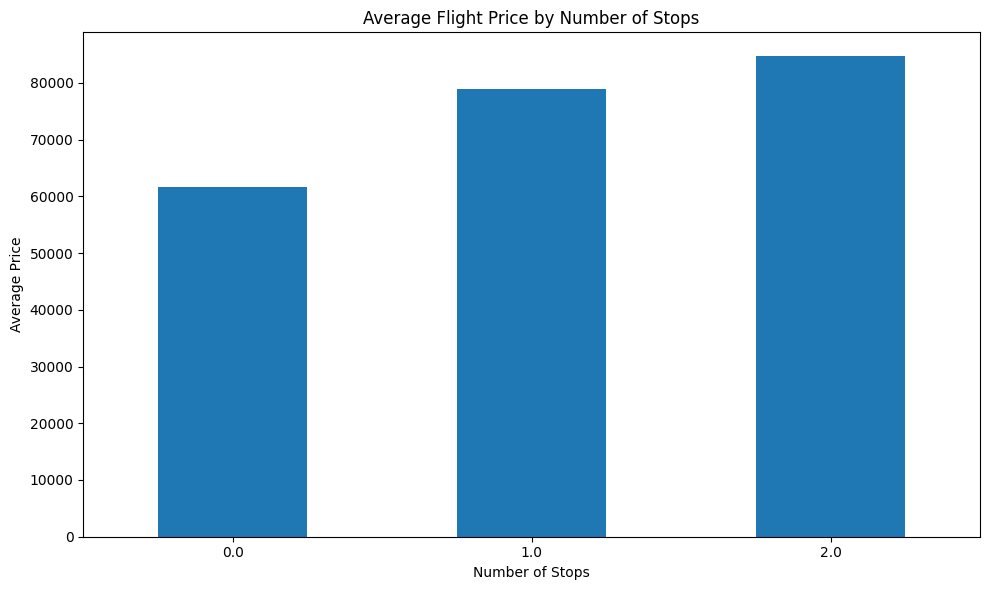

In [87]:
plt.figure(figsize=(10, 6))

stops_price["mean"].plot(kind="bar")

plt.title("Average Flight Price by Number of Stops")
plt.xlabel("Number of Stops")
plt.ylabel("Average Price")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "/content/stops_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
files.download("/content/stops_vs_price.png")

In [ ]:
print(stops_price)

The number of stops is associated with differences in observed flight prices. Non-stop flights have an average price of approximately ₹61,609, while flights with one and two stops average approximately ₹78,968 and ₹84,681 respectively. Therefore, in this dataset, connecting flights were not necessarily cheaper than direct flights.

Travelers should compare direct and connecting flights rather than automatically assuming that additional stops will reduce the fare.

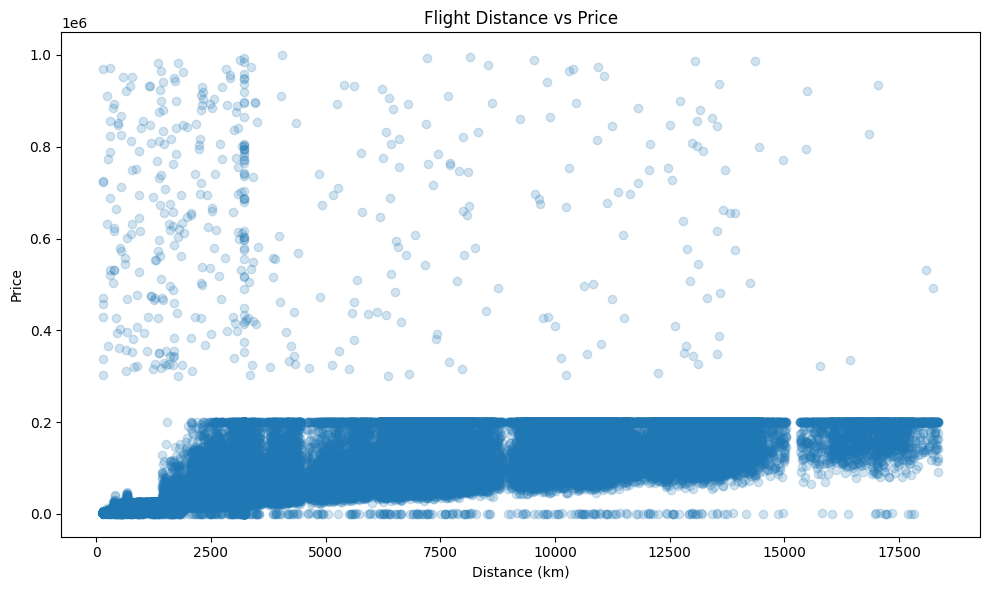

In [88]:
plt.figure(figsize=(10, 6))

plt.scatter(
    model_df["Distance_km"],
    model_df["Price"],
    alpha=0.2
)

plt.title("Flight Distance vs Price")
plt.xlabel("Distance (km)")
plt.ylabel("Price")

plt.tight_layout()

plt.savefig(
    "/content/distance_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
files.download("/content/distance_vs_price.png")

In [89]:
distance_price_corr = model_df[
    ["Distance_km", "Price"]
].corr().iloc[0, 1]

print("Correlation between distance and price:",
      distance_price_corr)

Correlation between distance and price: 0.6510056423972962


In [90]:
print("Correlation between distance and price:",
      distance_price_corr)

Correlation between distance and price: 0.6510056423972962


Flight distance has a moderately strong positive relationship with price, with a Pearson correlation of approximately 0.651. This indicates that longer flights generally tend to have higher observed prices. However, distance alone cannot explain all price variation because airline, travel class, booking time, route, and other factors also influence fares.

 Distance should be considered together with other fare-related factors when comparing flights.

In [91]:
booking_bins = [0, 7, 14, 30, 60, 90, 180, float("inf")]

booking_labels = [
    "0-7 days",
    "8-14 days",
    "15-30 days",
    "31-60 days",
    "61-90 days",
    "91-180 days",
    "181+ days"
]

model_df["Booking_Window"] = pd.cut(
    model_df["Days_Before_Departure"],
    bins=booking_bins,
    labels=booking_labels,
    include_lowest=True
)

In [92]:
booking_summary = (
    model_df
    .groupby("Booking_Window", observed=True)["Price"]
    .agg(["mean", "median", "count"])
)

print(booking_summary)

                        mean     median  count
Booking_Window                                
0-7 days        89755.707201  68093.435  21916
8-14 days       76308.592092  52688.565  16392
15-30 days      69624.911651  45514.815  20740
31-60 days      62572.236364  39133.925  16284
61-90 days      62173.631720  39685.130   3755
91-180 days     60592.549159  39106.030  11171


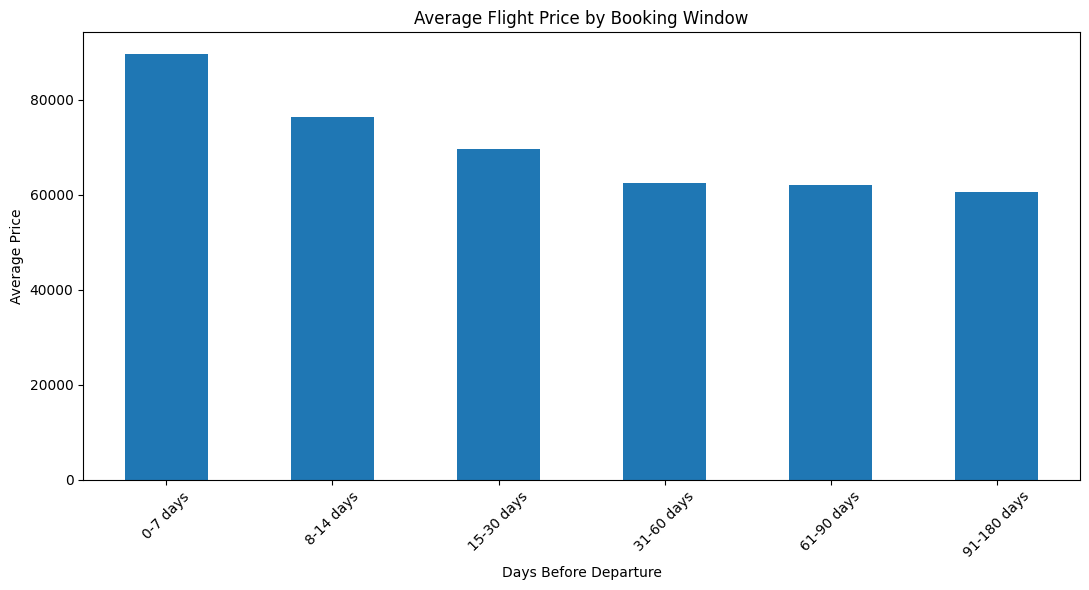

In [93]:
plt.figure(figsize=(11, 6))

booking_summary["mean"].plot(kind="bar")

plt.title("Average Flight Price by Booking Window")
plt.xlabel("Days Before Departure")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/content/booking_window_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
files.download("/content/booking_window_vs_price.png")

In [94]:
print(booking_summary)

                        mean     median  count
Booking_Window                                
0-7 days        89755.707201  68093.435  21916
8-14 days       76308.592092  52688.565  16392
15-30 days      69624.911651  45514.815  20740
31-60 days      62572.236364  39133.925  16284
61-90 days      62173.631720  39685.130   3755
91-180 days     60592.549159  39106.030  11171


Booking time shows a clear relationship with observed flight prices. Flights booked 0–7 days before departure have the highest average price at approximately ₹89,756, while flights booked 91–180 days in advance have the lowest observed average price at approximately ₹60,593. The median prices follow a similar pattern.

Travelers seeking lower fares should consider booking well in advance rather than waiting until the final week before departure. Based on this dataset, the 91–180 day window had the lowest observed average fare among the available booking windows.

In [95]:
season_price = (
    model_df
    .groupby("Season")["Price"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

print(season_price)

                 mean     median  count
Season                                 
Summer   77259.262787  53335.730  21810
Winter   75940.322357  53226.885  21094
Unknown  72868.151168  47997.170   4282
Autumn   70129.271482  46108.325  14458
Monsoon  69139.747235  45468.090  28614


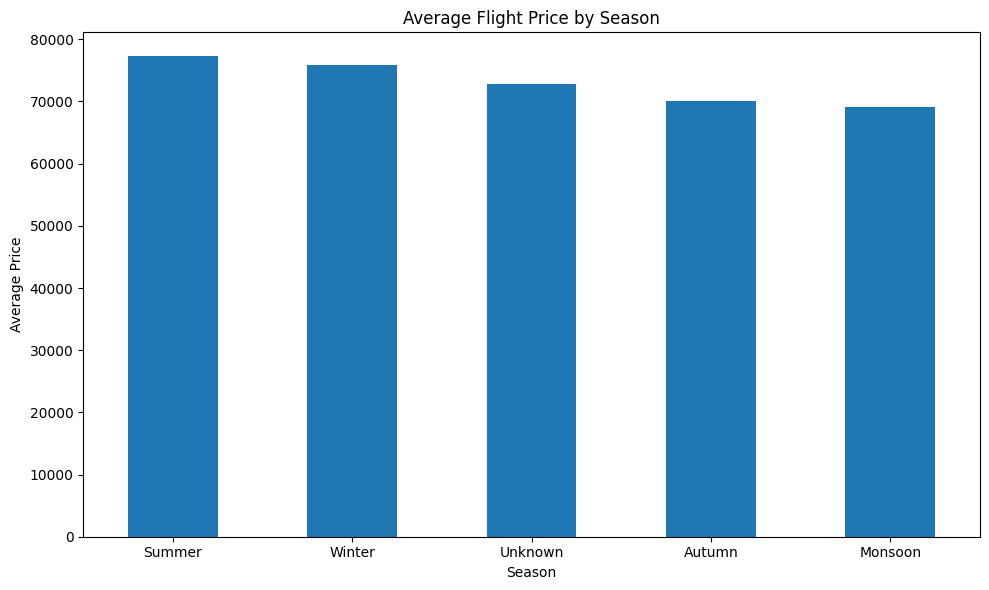

In [96]:
plt.figure(figsize=(10, 6))

season_price["mean"].plot(kind="bar")

plt.title("Average Flight Price by Season")
plt.xlabel("Season")
plt.ylabel("Average Price")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "/content/season_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
files.download("/content/season_vs_price.png")

In [97]:
print(season_price)

                 mean     median  count
Season                                 
Summer   77259.262787  53335.730  21810
Winter   75940.322357  53226.885  21094
Unknown  72868.151168  47997.170   4282
Autumn   70129.271482  46108.325  14458
Monsoon  69139.747235  45468.090  28614


Seasonality is associated with differences in observed flight prices. Summer has the highest average fare at approximately ₹77,259, followed by Winter at approximately ₹75,940. Monsoon has the lowest average fare among known seasons at approximately ₹69,140.

Recommendation: Travelers with flexible schedules may compare fares across seasons, as the dataset suggests that Monsoon travel can have lower average observed fares than Summer and Winter.

the analysis indicates that flight prices are influenced by multiple interacting factors rather than a single variable. Travel class, airline, booking time, distance, number of stops, and season all show meaningful associations with observed prices. Among these, travel class and booking timing show particularly clear differences in average fares, while distance has a Pearson correlation of approximately 0.651 with price. These findings provide the basis for the predictive modeling stage, where multiple features will be considered simultaneously rather than relying on individual factors.

In [98]:
numerical_features = [
    "Duration_Minutes",
    "Total_Stops_Clean",
    "Distance_km",
    "Days_Before_Departure",
    "Passenger_Count",
    "Journey_Year",
    "Journey_Month",
    "Journey_Day",
    "Journey_DayOfWeek",
    "Departure_Hour",
    "Arrival_Hour"
]
categorical_features = [
    "Airline",
    "Source",
    "Destination",
    "Travel_Class",
    "Season",
    "Aircraft_Type",
    "Booking_Channel"
]
missing_features = [
    col for col in model_features
    if col not in model_df.columns
]

print("Missing selected features:", missing_features)
print(model_df[model_features].isnull().sum())

Missing selected features: []
Airline                  0
Source                   0
Destination              0
Duration_Minutes         0
Total_Stops_Clean        0
Distance_km              0
Travel_Class             0
Days_Before_Departure    0
Season                   0
Aircraft_Type            0
Booking_Channel          0
Passenger_Count          0
Journey_Year             0
Journey_Month            0
Journey_Day              0
Journey_DayOfWeek        0
Departure_Hour           0
Arrival_Hour             0
dtype: int64


In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 72206
Testing samples: 18052


In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [101]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [102]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

TRAIN:

In [103]:
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Duration_Minutes',
                                                   'Total_Stops_Clean',
                                                   'Distance_km',
                                                   'Days_Before_Departure',
                                                   'Passenger_Count',
                                                   'Journey_Year',
                                                   'Journey_Month',
                                                   'Journey_Day',
                                                   'Journey_DayOfWeek',
                                                   'Departure_Hour',
                                                   'Arrival_Hour']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Airline', 'Source',
                                                   'Destination',
                                                   'Travel_Class', 'Season',
                                                   'Aircraft_Type',
                                                   'Booking_Channel'])])),
                ('model', LinearRegression())])

predict:


In [104]:
baseline_predictions = baseline_model.predict(X_test)

In [105]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline Linear Regression")
print("--------------------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

Baseline Linear Regression
--------------------------
MAE : 23858.63295685009
RMSE: 52668.19460018085
R²  : 0.5547363112442765


In [108]:
from sklearn.ensemble import RandomForestRegressor
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=30,
                random_state=42,
                n_jobs=-1,
                min_samples_leaf=3,
                max_depth=15
            )
        )
    ]
)

TRAIN:

In [112]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Duration_Minutes',
                                                   'Total_Stops_Clean',
                                                   'Distance_km',
                                                   'Days_Before_Departure',
                                                   'Passenger_Count',
                                                   'Journey_Year',
                                                   'Journey_Month',
                                                   'Journey_Day',
                                                   'Journey_DayOfWeek',
                                                   'Departure_Hour',
                                                   'Arrival_Hour']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Airline', 'Source',
                                                   'Destination',
                                                   'Travel_Class', 'Season',
                                                   'Aircraft_Type',
                                                   'Booking_Channel'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_leaf=3,
                                       n_estimators=30, n_jobs=-1,
                                       random_state=42))])

In [114]:
rf_predictions = rf_model.predict(X_test)

In [115]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest")
print("-------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
-------------
MAE : 15593.056970947537
RMSE: 49182.54774052331
R²  : 0.611722288569872


In [116]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2
    ]
})

print(comparison)

               Model           MAE          RMSE        R2
0  Linear Regression  23858.632957  52668.194600  0.554736
1      Random Forest  15593.056971  49182.547741  0.611722


In [117]:
feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print(feature_importance.head(20))

                              Feature  Importance
0               num__Duration_Minutes    0.516034
1                    num__Distance_km    0.158301
2           cat__Travel_Class_Economy    0.087699
3          num__Days_Before_Departure    0.052622
4          cat__Travel_Class_Business    0.017171
5             cat__Travel_Class_First    0.017098
6              num__Total_Stops_Clean    0.012322
7                    num__Journey_Day    0.011165
8                  num__Journey_Month    0.010121
9                 num__Departure_Hour    0.009540
10                  num__Arrival_Hour    0.008109
11             num__Journey_DayOfWeek    0.006676
12          cat__Travel_Class_Unknown    0.006004
13  cat__Travel_Class_Premium Economy    0.005854
14               num__Passenger_Count    0.004486
15  cat__Booking_Channel_Travel Agent    0.001782
16         cat__Destination_Ahmedabad    0.001678
17                 cat__Season_Summer    0.001649
18     cat__Aircraft_Type_Airbus A350    0.001590


The Random Forest feature-importance analysis shows that Duration_Minutes is the most influential feature, contributing approximately 51.6% of the model's total feature importance. Distance_km is the second most important feature at approximately 15.8%. Together, these two variables account for approximately 67.4% of the model's feature importance. Travel Class, particularly Economy, and Days Before Departure are also important contributors.

This suggests that the model relies primarily on characteristics describing the scale and nature of the journey, while booking timing and cabin class provide additional predictive information.

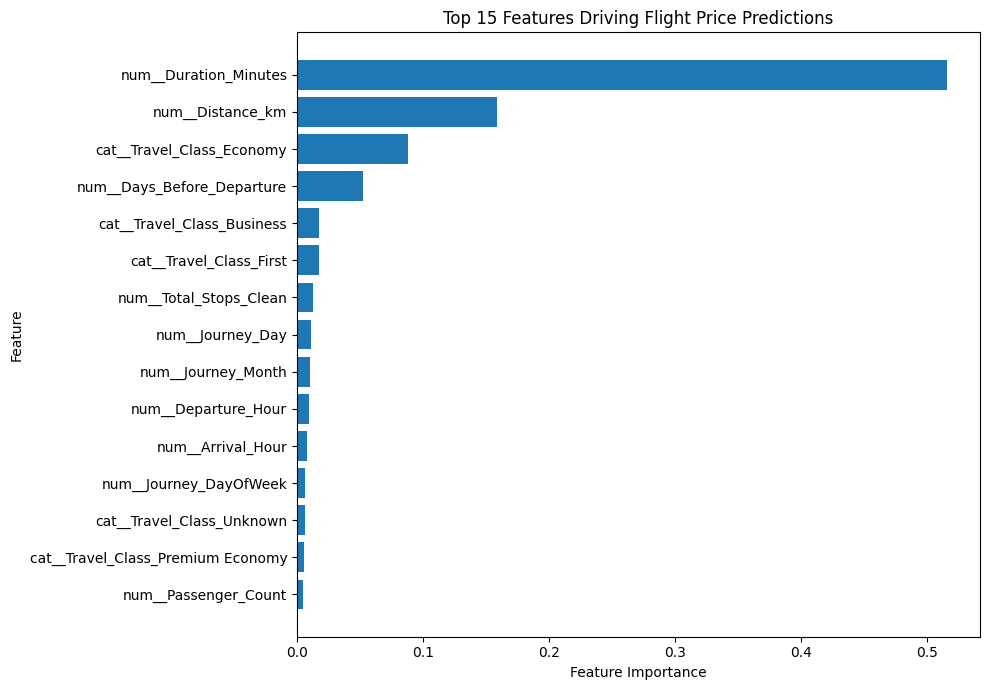

In [120]:
top_features = feature_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Driving Flight Price Predictions")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

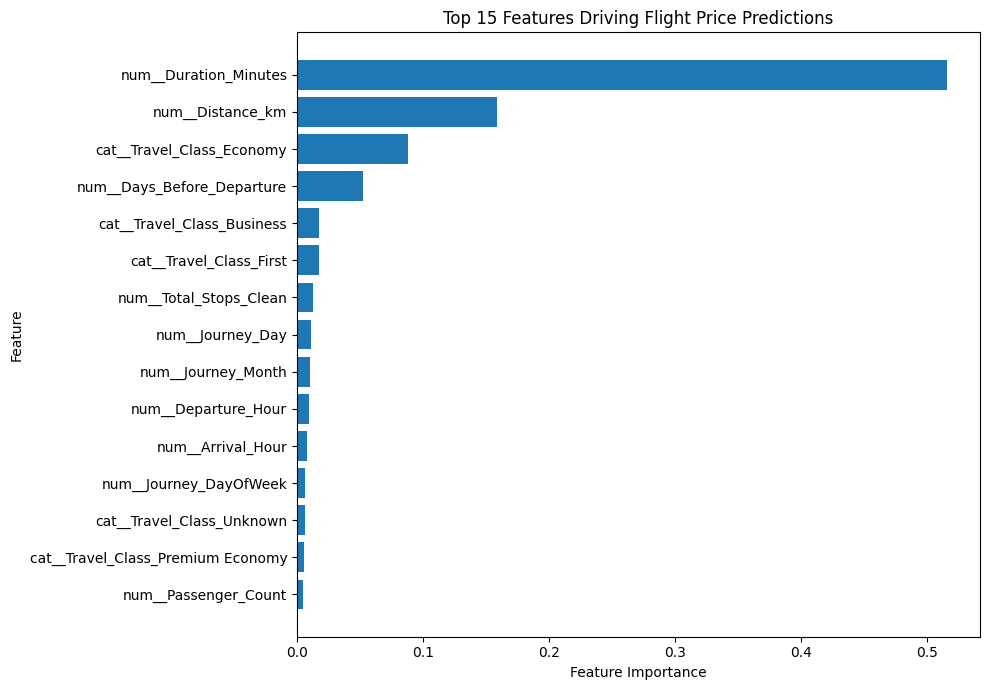

In [121]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Driving Flight Price Predictions")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "/content/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [127]:
from google.colab import files
files.download("/content/feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [124]:
import joblib

joblib.dump(
    rf_model,
    "/content/flight_price_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [125]:
import os

print(
    "File exists:",
    os.path.exists("/content/flight_price_model.pkl")
)

File exists: True


In [128]:
files.download("/content/flight_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [129]:
import os

model_path = "/content/flight_price_model.pkl"

print("File exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 ** 2)
    print(f"Model size: {size_mb:.2f} MB")

File exists: True
Model size: 13.29 MB


In [130]:
from google.colab import files

files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("/content/flight_price_model.pkl")

In [ ]:
files.download("/content/feature_importance.png")